In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from amoc_analysis import data, plotting
from amocatlas import read
from spectra_filtering import analysis, spectra # sonst amocatlas.spectra_filtering


In [2]:
ds = read.mocha()

MOC = ds["MOC"]

Loading 1 MOCHA 26°N dataset(s):
  0. Johns_2023_mht_data_2020_ERA5.zip: No description available



/Users/jakob/Desktop/SS2026/DataAnalysis/.venv/lib/python3.13/site-packages/amocatlas/reader_utils.py:80: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  ds = xr.open_dataset(file_path, **kwargs)


In [6]:
freq, psd = spectra.raw_periodogram(MOC, dt_days = 0.5)
freq2, psd2 = spectra.welch_psd(MOC,dt_days = 0.5,overlap = 0.5, segment_length=365*5, window = "hann")

Used zero-padding for last segment. Padded0 zeros.
Used zero-padding for last segment. Padded0 zeros.
Used zero-padding for last segment. Padded0 zeros.
Used zero-padding for last segment. Padded0 zeros.
Used zero-padding for last segment. Padded0 zeros.
Used zero-padding for last segment. Padded0 zeros.
Used zero-padding for last segment. Padded0 zeros.
Used zero-padding for last segment. Padded0 zeros.
Used zero-padding for last segment. Padded0 zeros.
Used zero-padding for last segment. Padded0 zeros.
Used zero-padding for last segment. Padded0 zeros.
Used zero-padding for last segment. Padded0 zeros.


In [4]:
spectra.parseval_ratio(MOC,freq,psd)

0.9872806899635366

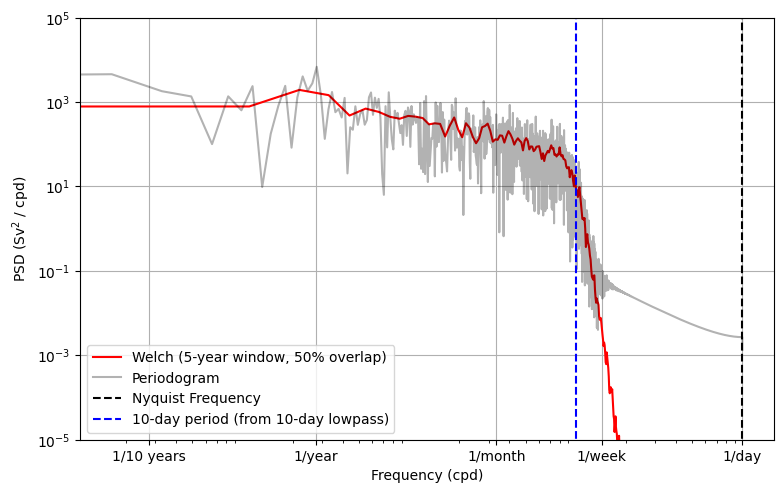

In [5]:
plt.figure(figsize=[8,5])
plt.loglog(freq2,psd2, color = "red", label = "Welch (5-year window, 50% overlap)")
plt.loglog(freq,psd, color = "k", alpha = 0.3, label = "Periodogram")
plt.grid()
#plt.ylim(1e-7,1e4)
plt.xlabel("Frequency (cpd)")
plt.ylabel(f"PSD (Sv$^2$ / cpd)")
plt.tight_layout()
plt.xticks([1,1/7,1/30,1/365,1/3650], ["1/day","1/week","1/month","1/year","1/10 years"])
plt.vlines(1,0,1e5,color = "k", ls = "--", label = "Nyquist Frequency")
plt.vlines(1/10,0,1e5,color = "blue", ls = "--", label = "10-day period (from 10-day lowpass)")
plt.ylim(1e-5,1e5)
plt.legend()
plt.savefig("../figures/mocha_PSD.pdf")
plt.show()